# Convolutional Neural Network with Keras


## Table of Contents

1. [Convolutional Neural Network with One Set of Convolutional and Pooling Layers](#Convolutional-Neural-Network-with-One-Set-of-Convolutional-and-Pooling-Layers)
2. [Convolutional Neural Network with Two Sets of Convolutional and Pooling Layers](#Convolutional-Neural-Network-with-Two-Sets-of-Convolutional-and-Pooling-Layers)

In [44]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # suppress the warning messages due to the GPU architechture

## Import Keras and Packages


In [45]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

from keras.layers import Conv2D # to add convolutional layers
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten # to flatten data for fully connected layers

from keras.models import Model # just to visualize the convolutional filters

## Convolutional Neural Network with One Set of Convolutional and Pooling Layers


In [46]:
# import data
from keras.datasets import mnist

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

X_train[0].shape

(28, 28, 1)

Let's normalize the pixel values to be between 0 and 1


In [47]:
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

In [48]:
# convert the target variable into binary categories

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1] # number of categories

In [49]:
def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

In [50]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
300/300 - 2s - 7ms/step - accuracy: 0.9183 - loss: 0.2907 - val_accuracy: 0.9711 - val_loss: 0.0962
Epoch 2/10
300/300 - 1s - 2ms/step - accuracy: 0.9760 - loss: 0.0819 - val_accuracy: 0.9806 - val_loss: 0.0576
Epoch 3/10
300/300 - 1s - 2ms/step - accuracy: 0.9837 - loss: 0.0555 - val_accuracy: 0.9854 - val_loss: 0.0450
Epoch 4/10
300/300 - 1s - 2ms/step - accuracy: 0.9873 - loss: 0.0433 - val_accuracy: 0.9861 - val_loss: 0.0439
Epoch 5/10
300/300 - 1s - 2ms/step - accuracy: 0.9896 - loss: 0.0357 - val_accuracy: 0.9862 - val_loss: 0.0417
Epoch 6/10
300/300 - 1s - 2ms/step - accuracy: 0.9915 - loss: 0.0283 - val_accuracy: 0.9863 - val_loss: 0.0390
Epoch 7/10
300/300 - 1s - 2ms/step - accuracy: 0.9932 - loss: 0.0238 - val_accuracy: 0.9876 - val_loss: 0.0389
Epoch 8/10
300/300 - 1s - 2ms/step - accuracy: 0.9937 - loss: 0.0205 - val_accuracy: 0.9878 - val_loss: 0.0374
Epoch 9/10
300/300 - 1s - 2ms/step - accuracy: 0.9948 - loss: 0.0168 - val_accuracy: 0.9879 - val_loss: 0.0371
E

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       230,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,780 (2.65 MB)

 Trainable params: 231,926 (905.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 463,854 (1.77 MB)

In [52]:
# Get one image to play with

image = X_train[0:1]

print(image.shape)
answer = y_train[0]

prediction = model.predict(image, verbose=0)
predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Correct digit:", round(np.sum(answer * range(10))))

(1, 28, 28, 1)
Predicted digit: 5
Correct digit: 5


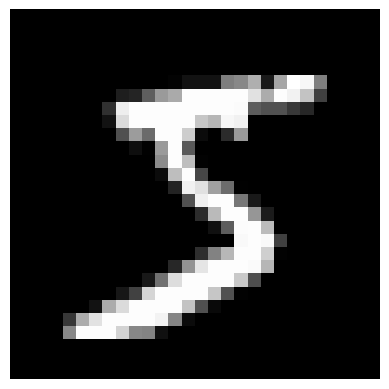

In [53]:
# show selected image
plt.imshow(image[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

In [54]:
# create a model that returns the outputs after the comvolutional layer
# we want to visualize the filters to get an intuition about what the model is doing
# similar thing can be done after the pooling layer, but it is less obvious in the fewer dimentions
conv_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output
)

conv_output = conv_model.predict(image)

print(conv_output.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(1, 24, 24, 16)


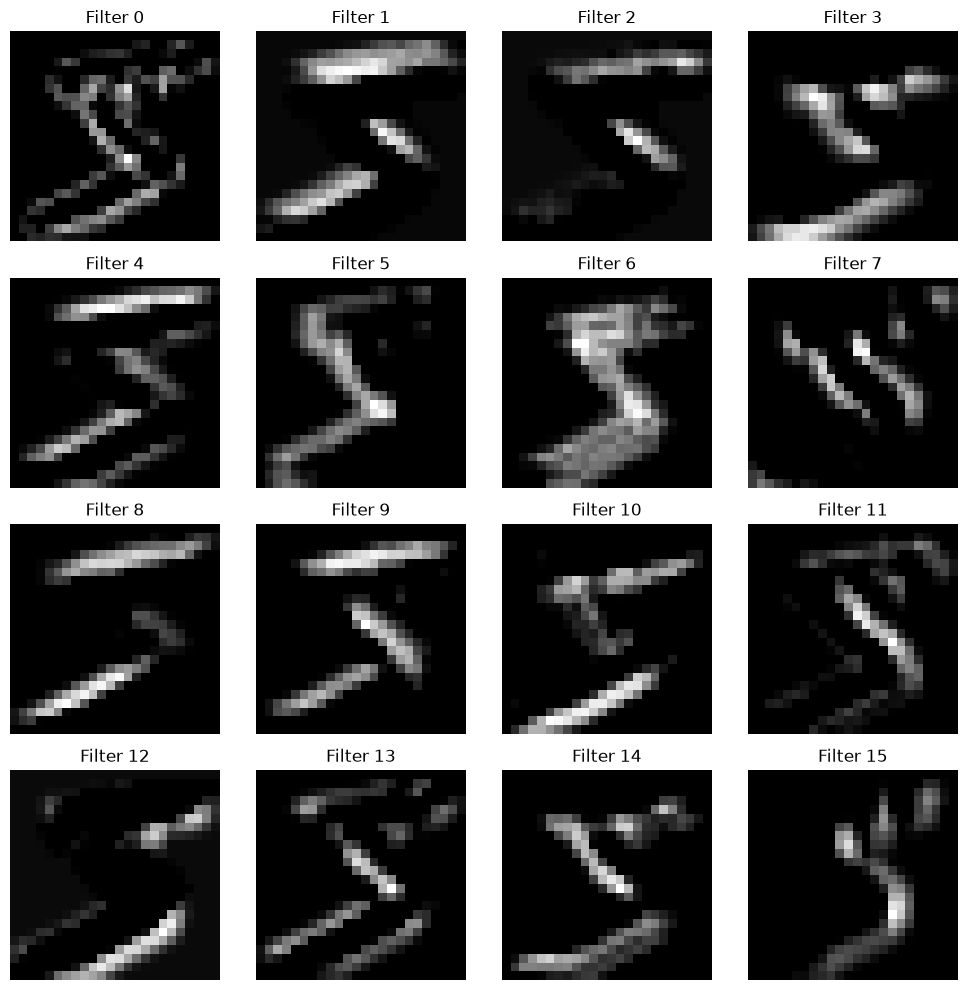

In [55]:
# remove the batch dimension
feature_maps = conv_output[0]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[:, :, i], cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

------------------------------------------


## Convolutional Neural Network with Two Sets of Convolutional and Pooling Layers


Let's redefine our convolutional model so that it has two convolutional and pooling layers instead of just one layer of each.


In [56]:
def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Conv2D(8, (2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

Now, let's call the function to create our new convolutional neural network, and then let's train it and evaluate it.


In [57]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=1024, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/25
59/59 - 5s - 85ms/step - accuracy: 0.6868 - loss: 1.1514 - val_accuracy: 0.8879 - val_loss: 0.3970
Epoch 2/25
59/59 - 1s - 9ms/step - accuracy: 0.9125 - loss: 0.2995 - val_accuracy: 0.9367 - val_loss: 0.2151
Epoch 3/25
59/59 - 1s - 9ms/step - accuracy: 0.9455 - loss: 0.1828 - val_accuracy: 0.9573 - val_loss: 0.1396
Epoch 4/25
59/59 - 1s - 9ms/step - accuracy: 0.9603 - loss: 0.1343 - val_accuracy: 0.9643 - val_loss: 0.1111
Epoch 5/25
59/59 - 1s - 9ms/step - accuracy: 0.9678 - loss: 0.1093 - val_accuracy: 0.9710 - val_loss: 0.0947
Epoch 6/25
59/59 - 1s - 9ms/step - accuracy: 0.9717 - loss: 0.0953 - val_accuracy: 0.9733 - val_loss: 0.0873
Epoch 7/25
59/59 - 1s - 9ms/step - accuracy: 0.9748 - loss: 0.0850 - val_accuracy: 0.9764 - val_loss: 0.0750
Epoch 8/25
59/59 - 1s - 9ms/step - accuracy: 0.9773 - loss: 0.0759 - val_accuracy: 0.9775 - val_loss: 0.0690
Epoch 9/25
59/59 - 1s - 9ms/step - accuracy: 0.9783 - loss: 0.0714 - val_accuracy: 0.9781 - val_loss: 0.0657
Epoch 10/25
59/59 

In [58]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 8)      │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,140 (258.36 KB)

 Trainable params: 22,046 (86.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,094 (172.25 KB)